# **Model estimation**

**MSc Thesis Euan Bronsky**

**Notebook number: 3**

This notebook focuses on the estimation of the various implied volatility surface models. The analysis starts by preparing the data, selecting representative contracts, and creating a train-test split. The selected data are then used to estimate several dynamic specifications.

--------------------------

- **Import dependencies**

In [1]:
%reset -f
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sympy.abc import theta
from patsy import dmatrix
from statsmodels.tsa.api import VAR
import statsmodels.api as sm
import pickle
from patsy import build_design_matrices
from scipy.stats import norm
from matplotlib import cm
from matplotlib.colors import LinearSegmentedColormap
import statsmodels.formula.api as smf
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

- **Preliminary data adjustments**

In [2]:
# Import data
data = pd.read_parquet("/Users/euanbronsky/Downloads/data_final_final.parquet")

# Locate the correct indices
data_select = data.loc[data.groupby(['quote_date', 'moneyness_group', 'maturity_group'])['distance'].idxmin()]

# Maintain only groups with length 24 and sort the dates
data_select = data_select.groupby('quote_date').filter(lambda x: len(x) == 24)

- **Train and test split**

In [3]:
# Extract dates
dates = np.sort(data_select['quote_date'].unique())
split = int((2 / 3) * len(dates))
train_dates = dates[:split]
test_dates = dates[split:]

# Create a train and test split and ensure fixed order
x_train = data_select[data_select['quote_date'].isin(train_dates)].copy().sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)
x_test = data_select[data_select['quote_date'].isin(test_dates)].copy().sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

# **1. Five Factors + VAR(1) model**

---------------------------------------

The first model is the static regression plus time series dynamics model. It represents the simplest possible model, but allows for a direct comparison between the two-step approach and the one-step state-space aproach. In the first step, teh implied volatility surface is estimated each day cross-sectionally using a static regression. In the second step, time-series dynamics are imposed on the estimated coefficients. In particular, the cross-sectional representation entails the five factor model:

$$    \log \sigma_i = \beta_0 + \beta_1 m_i + \beta_2 m_i^2  + \beta_3 \tau_i  +\beta_4 m_i \tau_i + \varepsilon_{i} $$

$\log \sigma_i$ is the log implied volatility of option $i$, $m_i$ is the moneyness, $m_i^2$ is the squared moneyness to allow curvature effects, $\tau_i$ is the time to maturity in years, $m_i \tau_i$ is the interaction term, $\beta_j, j = 0,...,4$ denote the slope coefficients, and $\varepsilon_i$ the error term. Subsequently, the time-series dynamics are estimated using a simple VAR(1) model:

$$    \hat \beta_t = \mu + \Phi \hat \beta_{t-1} + u_t, \qquad u_t \sim N(0, \Omega) $$

$\mu$ is a vector of intercepts, $\Phi$ contains the lagged relationships between the beta coefficients, and $u_t$ is a vector of shocks.


- **Step 1: Estimation**

In [4]:
# Estimation function
def estimate_daily_betas(data):

    # Create empty lists
    betas = []
    dates = []

    # Loop over the grouped data
    for date, group in data.groupby('quote_date'):

        # Regressor matrix
        X = group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']]

        # Dependent variables
        y = group['log_iv']

        # Apply OLS
        model = sm.OLS(y, X)
        result = model.fit()

        # Store results in the lists
        betas.append(result.params)
        dates.append(date)

    # Create dataframe to store results
    df_betas = pd.DataFrame(betas, index=dates)
    df_betas.index.name = 'quote_date'
    df_betas = df_betas.sort_index()

    # Fit the VAR(1) model
    model = VAR(df_betas)
    result = model.fit(1)

    # Extract the parameters
    omega = result.params.loc['const'].values
    Phi = result.params.iloc[1:].T.values

    # Return the results
    return df_betas, result, omega, Phi

- **Apply the functions**

In [5]:
# Apply the functions
df_betas_train, result, omega, Phi = estimate_daily_betas(x_train)

/Users/euanbronsky/PyCharmMiscProject/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


- **Save the results**

In [6]:
# Store relevant results
static_results = {

    # Estimation output
    'df_betas': df_betas_train,

    # Parameters
    'result': result,
    'omega': omega,
    'Phi': Phi,

    # Data
    'x_train': x_train,
    'x_test': x_test}

# Save using Pickle
with open('1first_results.pkl', 'wb') as f:
    pickle.dump(static_results, f)

# **2: Five factors + VAR(1) in state-space**

----------------------------------------------

The nmext model entails the five factor cross-sectional representation, where the time-series dynamics are simultaneously estimated using a maximum likelihood state-space approach. This means that the shape of the implied volatility surface and the evolution of its factors over time are estimated jointly in one framework. Compared to the two-step model, this approach avoids treating the estimated factors as fixed observations and instead accounts for uncertainty in latent factor estimates. The cross sectional representation remains the same, altough now represented in matrix-vector form:

$$\log IV_t = M_t \beta_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, H_t) $$

Similarly, the time-series evolution remains the same as in the previous model:

$$ \beta_{t+1} = \mu + \Phi \beta_{t} + \eta_t $$

- **Prepare groups function**

In [7]:
# Group preparing function
def prepare_groups(x):

    # Sort values
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Extract dates and create empty lists
    dates = np.sort(x['quote_date'].unique())
    y_groups = []
    Z_groups = []

    # Loop over dates
    for date in dates:

        # Extract groups
        group = x[x['quote_date'] == date]

        # Extract relevant variables and append to lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[['constant', 'M', 'moneyness_squared', 'T', 'interaction']].to_numpy(dtype=float))

    # return the results
    return dates, y_groups, Z_groups

- **Kalman estimation function**

To estimate the model, it is case into state-space representation, after which teh goal is to estimate the following set of recursive equations:

\begin{equation}
\begin{aligned}
v_t &= y_t - Z_t a_t, & F_t &= Z_t P_t Z_t^\top + H_t, \\
a_{t|t} &= a_t + P_t Z_t^\top F_t^{-1} v_t, & P_{t|t} &= P_t - P_t Z_t^\top F_t^{-1} Z_t P_t, \\
a_{t+1} &= c + T a_t + K_t v_t, & P_{t+1} &= T P_t T^{\top} + Q_t - K_t F_t K_t^{\top} .
\end{aligned}
\end{equation}

these quantities are then used to construct the likelihood function. In particular, the prediction errors and their variances determine how likely the observed data are under the model, allowing the parameters to be estimated by maximum likelihood. To gain efficiency, a collapsed estimation approach is conducted. This condenses the large 24-dimensional state vector into a 5-dimensional one, while retaining all possible information, thereby reducing the computational burden associated with the inversion of large matrices.

In [8]:
# Kalman estimation function
def kalman_est(par, y_groups, Z_groups):

    # Extract parameters
    c = par[:5]
    T = np.diag(np.tanh(par[5:10] / 2))
    Q = np.diag(np.exp(par[10:15]))
    sigma2 = np.exp(par[15:])

    # Extract n and p
    n_dates = len(y_groups)
    p = len(c)

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    llik = np.zeros(n_dates)

    # Initialize using unconditional moments
    at_pred[:, 0] = np.linalg.inv(np.eye(p) - T) @ c
    Pt_pred[0, :, :] = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

    # Loop over the series
    for t in range(n_dates):

        # Extract arrays
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Series length
        Nt = len(yt)

        # Measurement equation innovation covariance matrix and inverse
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        # Auxiliary variables
        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        # Compute inverse and collapsed variable
        A_inv = np.linalg.inv(A)
        yt_star = A_inv @ b

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:, t]
        Ft = Pt_pred[t, :, :] + Ht_star

        # Prediction error variance inverse
        Ft_inv = np.linalg.inv(Ft)
        Ft_inv_vt = Ft_inv @ vt

        # Compute log-determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        sign_Ht, logdet_Ht = np.linalg.slogdet(Ht)
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5 * len(yt_star) * np.log(2 * np.pi) - 0.5 * logdet_Ft - 0.5 * (vt.T @ Ft_inv_vt)
        llik[t] = llik_star - 0.5 * (logdet_Ht - logdet_Ht_star) - 0.5 * (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
            Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -llik.sum()

- **Maximize the collapsed likelihood**

$$\ell(y_t;\psi) = c + \ell(y_t^* ;\psi) - \frac{n}{2} \log \bigl( \frac{|H|}{|H^*|}\bigr) - \frac{1}{2} \sum^n_{t=1} e_t^{\top} H^{-1} e_t$$

In [9]:
# Minimize the likelihood
def minimize_llik(x):

    # Extract the groups
    dates, y_groups, Z_groups = prepare_groups(x)

    # Extract the parameters
    c_ini = [0.1] * 5
    T_ini = np.asarray([0.7] * 5)
    Q_ini = [0.003] * 5
    sigma2_ini = [0.003] * 24

    # List of initial parameter values
    par_ini = list(c_ini) + list(2 * np.arctanh(T_ini)) + list(np.log(Q_ini)) + list(np.log(sigma2_ini))

    # Set counter
    counter = {'i': 0}
    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_est, par_ini, args=(y_groups, Z_groups), method='L-BFGS-B', callback=print_iter, options={
        "maxiter": 2000,
        "maxfun": 100000,
        "ftol": 1e-8,
        "gtol": 1e-5,
        "maxls": 50
    })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

Parameters are transformed using the exponential and hyperbolic tangent functions to ensure positivity and boundedness between -1 and 1.

In [10]:
# Transform the parameters
def transf_par(par):

    # Transform parameters
    c = par[:5]
    T = np.diag(np.tanh(par[5:10] / 2))
    Q = np.diag(np.exp(par[10:15]))
    sigma2 = np.exp(par[15:])

    # Return the results
    return c, T, Q, sigma2

- **Apply functions and display parameters**

Among reported metrics are the AIC and BIC:

$$AIC^{(m)} = -2 \mathcal{L}^{(m)}_{in} + 2k_m, \qquad BIC^{(m)} = -2 \mathcal{L}^{(m)}_{in} + k_m \log (n_{train}).$$

In [11]:
# Apply the functions
par_raw, llik, res = minimize_llik(x_train)
c, T, Q, sigma2 = transf_par(par_raw)

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Iteration 77
Iteratio

In [12]:
# Extract the parameters
par_vec = np.r_[c, np.diag(T), np.diag(Q), sigma2]

# Compute information criteria
n_obs = x_train['quote_date'].nunique()
k_params = len(par_vec)
aic = 2 * k_params - 2 * llik
hqic = 2 * np.log(np.log(n_obs)) * k_params - 2 * llik
bic = np.log(n_obs) * k_params - 2 * llik

# Index
index = (
        [f'c_{i}' for i in range(len(c))] +
        [f'T_{i}' for i in range(len(np.diag(T)))] +
        [f'q_{i}' for i in range(len(np.diag(Q)))] +
        [f'Sigma^2_{i}' for i in range(len(sigma2))])

# Store results in dataframe and display
df_par = pd.DataFrame({
    'params': par_vec
}, index=index)
df_par.loc['AIC'] = aic
df_par.loc['HQIC'] = hqic
df_par.loc['BIC'] = bic
df_par.loc['llik'] = llik
df_par

,params
c_0,-1.901353e-02
c_1,-4.605180e-03
c_2,-5.643299e-03
c_3,4.673736e-03
c_4,5.639785e-04
T_0,9.903568e-01
T_1,9.974227e-01
T_2,9.933820e-01
T_3,9.820023e-01
T_4,9.965288e-01


- **Filter the results**

In [13]:
# Prepare groups for efficiency
dates, y_groups, Z_groups = prepare_groups(data_select)

# extract number of dates and number of parameters
n_dates = len(y_groups)
p = len(c)

# Create empty array of predicted values and loglikelihood
at_pred = np.zeros((p, n_dates))
Pt_pred = np.zeros((n_dates, p, p))

# Create empty array of filtered values
at_filt = np.zeros((p, n_dates))
Pt_filt = np.zeros((n_dates, p, p))

# Initialize the predicted values
at_pred[:, 0] = np.linalg.inv(np.eye(p) - T) @ c
Pt_pred[0, :, :] = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

# Loop over the dates
for t in range(n_dates):

    # Extract the groups
    yt = y_groups[t]
    Zt = Z_groups[t]

    # Time varying dimension
    Nt = len(yt)

    # Measurement error covariance matrix
    Ht = np.diag(sigma2)

    # Compute prediction error, its variance, and its inverse
    vt = yt - Zt @ at_pred[:, t]
    Ft = Zt @ Pt_pred[t, :, :] @ Zt.T + Ht
    Ft_inv = np.linalg.inv(Ft)

    # Compute new filtered values
    at_filt[:, t] = at_pred[:, t] + Pt_pred[t, :, :] @ Zt.T @ Ft_inv @ vt
    Pt_filt[t, :, :] = Pt_pred[t, :, :] - Pt_pred[t, :, :] @ Zt.T @ Ft_inv @ Zt @ Pt_pred[t, :, :]

    # Compute the Kalman gain, predicted state estimate, and predicted state variance
    if t < n_dates - 1:
        Kt = T @ Pt_pred[t, :, :] @ Zt.T @ Ft_inv
        at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
        Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

- **Save the results**

In [14]:
# Store relevant results
var_results = {

    # Estimation output
    'df_par': df_par,

    # Parameters
    'c': c,
    'T': T,
    'Q': Q,
    'sigma2': sigma2,

    # Kalman states
    'at_filt': at_filt,
    'Pt_filt': Pt_filt,
    'at_pred': at_pred,
    'Pt_pred': Pt_pred,

    # Dates and groups
    'dates': dates,

    # Data
    'x_train': x_train,
    'x_test': x_test,

    # Variable info
    'basis_cols': ['constant', 'M', 'moneyness_squared', 'T', 'interaction']}

# Save using Pickle
with open('2model1_results.pkl', 'wb') as f:
    pickle.dump(var_results, f)

# **3: Five factors + OU process state-space**

----------------------------------------

Motivated by stationary mean-reverting dynamics in the preliminary analysis, the factor dynamics are replaced by a continuous time Ornstein-Uhlenbeck process. This specification is useful because it explicitly models the tendency of the factors to revert toward a long-run mean after shocks. As a result, temporary deviations in the implied volatility surface are not assumed to persist indefinitely. As such, the cross-sectional representation remains the same as previous:

$$ \log IV_t = M_t \beta_t + \varepsilon_t, \quad \varepsilon_t \sim N(0, H_t) $$

But the time-series dynamics are reexpressed to satisfy the OU process:

$$    d\beta_t = K(\Theta  - \beta_{t})dt + \Gamma dW_{t}^{\mathbb{P}}, \quad dW_t^{\mathbb{P}} \sim N(0, R dt)  $$

Here,  The diagonal matrix $K = \text{diag}(k_1,...,k_p) \in \mathbb{R}^{p \times p}$ contains the mean reversion rates. Each parameter $k_i$ describes how quickly coefficient $i$ is pulled back toward its long-run mean $\theta_i$, collected in the vector $\Theta = (\theta_1,...,\theta_p)^{\top} \in \mathbb{R}^{p}$. The diagonal matrix $\Gamma = \text{diag}(\gamma_1,...,\gamma_p) \in \mathbb{R}^{p \times p}$ contains the volatility parameters, where $\gamma_i$ governs the shock intensity of coefficient $i$. Finally,  $W_t^{\mathbb{P}} = (W_{1,t}^{\mathbb{P}}, ..., W_{p,t}^{\mathbb{P}})^{\top} \in \mathbb{R}^p$ denotes the vector of Brownian motions driving the latent coefficients, with quadratic covariance $dW_t dW_t^{\top} = R dt$, where $R = (\rho_{ij})^p_{i,j=1}$ is the Brownian correlation matrix.

- **Build a valid correlation matrix**

To ensure a valid correlation matrix, a Cholesky decomposition is conducted. First, a unit diagonal lower triangular matrix L is constructed, which allows construction of a covariance matrix via $\Sigma = LL^{\top}$. This is then standardized to obtain a valid correlation matrix $R = D^{-1/2}\Sigma D^{-1/2}$. This procedure decreases number of parameters to estimate while avoiding hard constraints.


In [12]:
# Build a valid correlation matrix
def build_R(r_params, p):

    # Build a lower-triangular matrix
    L = np.eye(p)
    idx = np.tril_indices(p, k=-1)
    L[idx] = r_params

    # Form a covariance-like matrix
    S = L @ L.T

    # Convert it into a correlation matrix
    d = np.sqrt(np.diag(S))
    R = S / np.outer(d, d)

    # Return the correlation matrix
    return R

- **Build covariance matrix with desired elements**

The covariance matrix satisfies $Q = \Omega \Omega^{\top} \in \mathbb{R}^{p \times p}$, which in particular satisfies $Q_{ij} = \rho_{ij}\gamma_i\gamma_j \frac{1 - e^{-(k_i + k_j)}}{k_i + k_j} $.

In [13]:
# Covariance building function
def build_Q(k, gamma, R):
    p = len(k)

    # Build Q entry by entry
    Q = np.zeros((p, p))
    for i in range(p):
        for j in range(p):
            Q[i, j] = (
                R[i, j]
                * gamma[i]
                * gamma[j]
                * (1 - np.exp(-(k[i] + k[j])))
                / (k[i] + k[j])
            )

    # Return the result
    return Q

- **Kalman estimation function**

The estimation principle is similar to before. The only difference is now the elements contained inside the state-space parameter. With the OU model more structure is imposed, yielding more additional parameters.

In [17]:
# Kalman estimation function
def kalman_est2(par, y_groups, Z_groups, p):

    # Extract parameters
    n_obs = len(y_groups[0])
    k = np.exp(par[:p])
    theta = par[p:2*p]
    gamma = np.exp(par[2*p:3*p])
    sigma2 = np.exp(par[3*p:3*p + n_obs])
    r_params = par[3*p + n_obs:]

    # Construct vectors and matrices
    R = build_R(r_params, p)
    Q = build_Q(k, gamma, R)
    T = np.diag(np.exp(-k))
    c = theta*(1 - np.exp(-k))

    # Extract n and p
    n_dates = len(y_groups)
    p = len(c)

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    llik = np.zeros(n_dates)

    # Initialize using unconditional moments
    at_pred[:, 0] = np.linalg.inv(np.eye(p) - T) @ c
    Pt_pred[0, :, :] = (np.linalg.inv(np.eye(p ** 2) - np.kron(T, T)) @ Q.reshape(-1, order='F')).reshape((p, p), order='F')

    # Loop over the series
    for t in range(n_dates):

        # Extract arrays
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Series length
        Nt = len(yt)

        # Measurement equation innovation covariance matrix and inverse
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        # Auxiliary variables
        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        # Compute inverse and collapsed variable
        A_inv = np.linalg.inv(A)
        yt_star = A_inv @ b

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:, t]
        Ft = Pt_pred[t, :, :] + Ht_star

        # Prediction error variance inverse
        Ft_inv = np.linalg.inv(Ft)
        Ft_inv_vt = Ft_inv @ vt

        # Compute log-determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        sign_Ht, logdet_Ht = np.linalg.slogdet(Ht)
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5 * len(yt_star) * np.log(2 * np.pi) - 0.5 * logdet_Ft - 0.5 * (vt.T @ Ft_inv_vt)
        llik[t] = llik_star - 0.5 * (logdet_Ht - logdet_Ht_star) - 0.5 * (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:, t + 1] = c + T @ at_pred[:, t] + Kt @ vt
            Pt_pred[t + 1, :, :] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -llik.sum()

- **Minimize the log likelihood**

In [18]:
# Minimize the likelihood
def minimize_llik2(x, p):

    # Extract the groups
    dates, y_groups, Z_groups = prepare_groups(x)

    n_obs = len(y_groups[0])

    # Initial parameters
    k = [0.05] * p
    theta = [0.0] * p
    gamma = [0.05] * p
    sigma2 = [0.0005] * n_obs
    r_params = [0.00] * (p * (p-1) // 2)

    # List of initial parameter values
    par_ini = list(np.log(k)) + list(theta) + list(np.log(gamma)) + list(np.log(sigma2)) + list(r_params)

    # Set counter
    counter = {'i': 0}

    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])


    bounds = (
        [(-5, 2)] * p
        + [(-5, 5)] * p
        + [(-10, 2)] * p
        + [(np.log(1e-8), np.log(1.0))] * n_obs
        + [(-5, 5)] * (p * (p - 1) // 2)
    )

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_est2, par_ini, args=(y_groups, Z_groups, p), method='L-BFGS-B', bounds=bounds,callback=print_iter, options={
        "maxiter": 2000,
        "maxfun": 100000,
        "ftol": 1e-8,
        "gtol": 1e-5,
        "maxls": 50
    })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

In [19]:
# Transform the parameters
def transform_par(par, p, n_obs):

    # Transform parameters
    k = np.exp(par[:p])
    theta = par[p:2*p]
    gamma = np.exp(par[2*p:3*p])
    sigma2 = np.exp(par[3*p:3*p + n_obs])
    r_params = par[3*p + n_obs:]

    # Build covariance and correlation matrices
    R = build_R(r_params, p)
    Q = build_Q(k, gamma, R)

    # Intercept and persistence matrix
    T_diag = np.exp(-k)
    T = np.diag(T_diag)
    c = theta * (1 - T_diag)

    # Return the results
    return k, theta, gamma, sigma2, R, Q, T, c

- **Obtain the results and display**

In [20]:
par_ou_raw, llik_ou, res_ou = minimize_llik2(x_train, p=5)
k_ou, theta_ou, gamma_ou, sigma2_ou, R_ou, Q_ou, T_ou, c_ou= transform_par(par_ou_raw, p = 5, n_obs = 24)

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40
Iteration 41
Iteration 42
Iteration 43
Iteration 44
Iteration 45
Iteration 46
Iteration 47
Iteration 48
Iteration 49
Iteration 50
Iteration 51
Iteration 52
Iteration 53
Iteration 54
Iteration 55
Iteration 56
Iteration 57
Iteration 58
Iteration 59
Iteration 60
Iteration 61
Iteration 62
Iteration 63
Iteration 64
Iteration 65
Iteration 66
Iteration 67
Iteration 68
Iteration 69
Iteration 70
Iteration 71
Iteration 72
Iteration 73
Iteration 74
Iteration 75
Iteration 76
Iteration 77
Iteratio

In [21]:
# Extract the parameters
idx_ou = np.tril_indices(5, k=-1)
corr_params_ou = R_ou[idx_ou]

# Store parameters in vector
par_vec_ou = np.r_[k_ou, theta_ou, gamma_ou, sigma2_ou, corr_params_ou]

# Compute AIC and BIC
k_params_ou = len(par_vec_ou)
aic_ou = 2 * k_params_ou - 2 * llik_ou
hqic_ou = 2 * np.log(np.log(n_obs)) * k_params_ou - 2 * llik_ou
bic_ou = np.log(n_obs) * k_params_ou - 2 * llik_ou

# Index
index_ou = (
        [f'k_{i}' for i in range(len(k_ou))] +
        [f'theta_{i}' for i in range(len(theta_ou))] +
        [f'gamma_{i}' for i in range(len(gamma_ou))] +
        [f'Sigma^2_{i}' for i in range(len(sigma2_ou))] +
        [f'r_{i}' for i in range(len(corr_params_ou))])

# Store results in dataframe
df_par_ou = pd.DataFrame({
    'params': par_vec_ou
}, index=index_ou)
df_par_ou.loc['AIC'] = aic_ou
df_par_ou.loc['HQIC'] = hqic_ou
df_par_ou.loc['BIC'] = bic_ou
df_par_ou.loc['llik'] = llik_ou
df_par_ou

,params
k_0,0.011232
k_1,0.012766
k_2,0.015150
k_3,0.022846
k_4,0.017271
theta_0,-1.975958
theta_1,-1.899374
theta_2,-1.035802
theta_3,0.270160
theta_4,0.286642


- **Filter the results**

In [22]:
# Number of elements in state vector
p_ou = len(c_ou)

# Create empty array for predicted values
at_pred_ou = np.zeros((p_ou, n_dates))
Pt_pred_ou = np.zeros((n_dates, p_ou, p_ou))

# Create empty array for filtered values
at_filt_ou = np.zeros((p_ou, n_dates))
Pt_filt_ou = np.zeros((n_dates, p_ou, p_ou))

# Initialize the predicted array with unconditional moments
at_pred_ou[:, 0] = np.linalg.inv(np.eye(p_ou) - T_ou) @ c_ou
Pt_pred_ou[0, :, :] = (np.linalg.inv(np.eye(p_ou ** 2) - np.kron(T_ou, T_ou)) @ Q_ou.reshape(-1, order='F')).reshape((p_ou, p_ou), order='F')

# Loop over the dates
for t in range(n_dates):

    # Extract groups
    yt_ou = y_groups[t]
    Zt_ou = Z_groups[t]

    # Observation vector dimension
    Nt_ou = len(yt_ou)

    # Measurement innovation covariance matrix
    Ht_ou = np.diag(sigma2_ou) # * np.eye(Nt_ou)

    # Prediction error, its variance, and its inverse
    vt_ou = yt_ou - Zt_ou @ at_pred_ou[:, t]
    Ft_ou = Zt_ou @ Pt_pred_ou[t, :, :] @ Zt_ou.T + Ht_ou
    Ft_inv_ou = np.linalg.inv(Ft_ou)

    # Compute filtered values
    at_filt_ou[:, t] = at_pred_ou[:, t] + Pt_pred_ou[t, :, :] @ Zt_ou.T @ Ft_inv_ou @ vt_ou
    Pt_filt_ou[t, :, :] = Pt_pred_ou[t, :, :] - Pt_pred_ou[t, :, :] @ Zt_ou.T @ Ft_inv_ou @ Zt_ou @ Pt_pred_ou[t, :, :]

    # Compute the Kalman gain, predicted state estimate, and predicted state variance
    if t < n_dates - 1:
        Kt_ou = T_ou @ Pt_pred_ou[t, :, :] @ Zt_ou.T @ Ft_inv_ou
        at_pred_ou[:, t + 1] = c_ou + T_ou @ at_pred_ou[:, t] + Kt_ou @ vt_ou
        Pt_pred_ou[t + 1, :, :] = T_ou @ Pt_pred_ou[t, :, :] @ T_ou.T + Q_ou - Kt_ou @ Ft_ou @ Kt_ou.T

- **Save the results**

In [23]:
# Store relevant results
ou_results = {

    # Estimation output
    'df_par': df_par_ou,

    # Parameters
    'c': c_ou,
    'T': T_ou,
    'Q': Q_ou,
    'R': R_ou,
    'sigma2': sigma2_ou,

    # Kalman states
    'at_filt': at_filt_ou,
    'Pt_filt': Pt_filt_ou,
    'at_pred': at_pred_ou,
    'Pt_pred': Pt_pred_ou,

    # Dates
    'dates': dates,

    # Variable info
    'basis_cols': ['constant', 'M', 'moneyness_squared', 'T', 'interaction']
}

# Save using Pickle
with open('3model_ou_results.pkl', 'wb') as f:
    pickle.dump(ou_results, f)

# **4. Spline basis + OU process state-space**

---------------------------------

To allow for more flexibility in the cross-sectional specification, a spline basis model is constructed. This is useful because the shape of the volatility skew may differ between short- and long-dated options, and such local differences are not well represented by a global set of linear, quadratic, or interaction terms. By using locally defined basis functions, the model can capture nonlinear patterns in specific regions of the surface without enforcing the samee functional shape across all options. The cross sectional specification is characterized by:

$$\log \sigma_{t}(m_i, \tau_i) = \beta_{0,t}
+ \underbrace{\sum^{K_m}_{j=1} \beta_{j,t}^{(m)} \Phi_j(m_{i,t})}_{\text{moneyness effect}}
+ \underbrace{\sum^{K_\tau}_{h=1} \beta_{h,t}^{(\tau)} \Psi_h(\tau_{i,t})}_{\text{maturity effect}}
+ \underbrace{\sum^{K_m}_{j=1} \sum^{K_\tau}_{h=1} \beta_{jh,t}^{(m,\tau)} \Phi_h(m_{i,t}) \Psi_h(\tau_{i,t})}_{\text{interaction effect}}
+ \varepsilon_{i,t}, \qquad \varepsilon_{i,t} \sim N(0, \sigma^2_{\varepsilon, t}) $$

While the time-series dynamics retain the OU process:

$$     d\beta_t = K(\Theta  - \beta_{t})dt + \Gamma dW_{t}^{\mathbb{P}}, \quad dW_t^{\mathbb{P}} \sim N(0, R dt) $$

- **Construct the training basis matrices**

In [4]:
# Spline function for training data
def build_train_spline_data(x):

    # Sort the values
    x = x.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]
    ).reset_index(drop=True)

    # Construct moneyness basis
    m_basis = dmatrix(
        "bs(M, df=3, degree=3, include_intercept=False) - 1",
        data=x,
        return_type="dataframe")

    # Construct maturity basis
    tau_basis = dmatrix(
        "bs(T, df=3, degree=3, include_intercept=False) - 1",
        data=x,
        return_type="dataframe")

    # Extract information
    m_design_info = m_basis.design_info
    tau_design_info = tau_basis.design_info

    # Construct the columns
    m_basis.columns = [f"m_basis_{j}" for j in range(m_basis.shape[1])]
    tau_basis.columns = [f"tau_basis_{j}" for j in range(tau_basis.shape[1])]

    # Construct the interaction basis
    interaction_basis = pd.concat({
        f"{m_col}_x_{tau_col}": m_basis[m_col] * tau_basis[tau_col]
        for m_col in m_basis.columns
        for tau_col in tau_basis.columns
    }, axis=1)

    # Construct the regressor matrix and the basis columns
    Z_df = pd.concat([m_basis, tau_basis, interaction_basis], axis=1)
    basis_cols = ["constant"] + Z_df.columns.tolist()

    # Construct DF of all data
    x_spline = pd.concat([x, Z_df], axis=1)

    # Return the results
    return x_spline, basis_cols, m_design_info, tau_design_info

- **Construct the testing basis matrices**

In [5]:
# Spline testing function
def build_spline_data(x, keep_24=False):

    # Sort the data
    x = x.sort_values(
        ["quote_date", "moneyness_group", "maturity_group"]
    ).reset_index(drop=True)

    # Ensure it doesn't go outsize the range of possible values
    M_min, M_max = x_train["M"].min(), x_train["M"].max()
    dte_min, dte_max = x_train["T"].min(), x_train["T"].max()

    # Filter the data
    x_oos = x[
        (x["M"] >= M_min) &
        (x["M"] <= M_max) &
        (x["T"] >= dte_min) &
        (x["T"] <= dte_max)
    ].copy().reset_index(drop=True)

    # Construct the moneyness basis
    m_basis = build_design_matrices(
        [m_design_info],
        x_oos,
        return_type="dataframe"
    )[0]

    # Construct the maturity basis
    tau_basis = build_design_matrices(
        [tau_design_info],
        x_oos,
        return_type="dataframe"
    )[0]

    # Construct columns
    m_basis.columns = [f"m_basis_{j}" for j in range(m_basis.shape[1])]
    tau_basis.columns = [f"tau_basis_{j}" for j in range(tau_basis.shape[1])]

    # Construct interaction basis
    interaction_basis = pd.concat({
        f"{m_col}_x_{tau_col}": m_basis[m_col] * tau_basis[tau_col]
        for m_col in m_basis.columns
        for tau_col in tau_basis.columns
    }, axis=1)

    # Construct the regressor matrix and add it to data
    Z_df = pd.concat([m_basis, tau_basis, interaction_basis], axis=1)
    x_spline = pd.concat([x_oos, Z_df], axis=1)

    # Case where the bucketed data is used
    if keep_24:
        x_spline = (
            x_spline
            .groupby("quote_date")
            .filter(lambda z: len(z) == 24)
            .sort_values(['quote_date', 'moneyness_group', 'maturity_group'])
            .reset_index(drop=True))
        x_spline = x_spline[x_train_spline.columns]

    # Return the results
    return x_spline, basis_cols, m_design_info, tau_design_info

- **Concatenate results to get the full sample**

In [6]:
# Apply the training function
x_train_spline, basis_cols, m_design_info, tau_design_info = build_train_spline_data(x_train)

# Apply the testing function
x_test_spline, basis_cols, m_design_info, tau_design_info = build_spline_data(x_test,keep_24=True)

# Extract the full data including spline basis
data_spline_full, basis_cols, m_design_info, tau_design_info = build_spline_data(data,keep_24=False)

# Construct the full matrix
x_full_spline = (
    pd.concat([x_train_spline, x_test_spline], axis=0)
    .sort_values(['quote_date', 'moneyness_group', 'maturity_group'])
    .reset_index(drop=True))

- **Prepare groups**

In [7]:
# Group preparing function
def prepare_groups_spline(x):

    # Sort values
    x = x.sort_values(['quote_date', 'moneyness_group', 'maturity_group']).reset_index(drop=True)

    # Sort the dates
    dates = np.sort(x['quote_date'].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the groups
        group = x[x['quote_date'] == date]

        # Append the y and Z groups to the lists
        y_groups.append(group['log_iv'].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Kalman estimation function**

In [8]:
# Collapsed Kalman estimation function
def kalman_estimation_spline(par, y_groups, Z_groups):

    # Dimension of the state vector
    p = Z_groups[0].shape[1]

    # Specify the dates and number of unique dates
    n_dates = len(y_groups)
    n_obs = len(y_groups[0])

    # Parameters
    k = np.exp(par[:p])
    theta = par[p:2*p]
    c = theta* (1 - np.exp(-k))
    sigma2 = np.exp(par[2*p:2*p + n_obs])

    # Covariance matrix
    gamma = np.exp(par[2*p + n_obs:3*p + n_obs])
    r_params = par[3*p + n_obs:]
    R = build_R(r_params, p=p)
    Q = build_Q(k, gamma, R)

    # Constant transition matrix
    T = np.diag(np.exp(-k))

    # Specify the initial values
    at_init = np.linalg.inv(np.eye(p) - T) @ c
    Pt_init = (np.linalg.inv(np.eye(p**2) - np.kron(T, T)) @ Q.reshape(-1, order = 'F')).reshape((p,p), order = 'F')

    # Create empty arrays
    at_pred = np.zeros((p, n_dates))
    Pt_pred = np.zeros((n_dates, p, p))
    ll = np.zeros(n_dates)

    # Store the initial values
    at_pred[:,0] = at_init
    Pt_pred[0,:,:] = Pt_init

    # Loop over the dates
    for t in range(n_dates):

        # Extract the groups
        yt = y_groups[t]
        Zt = Z_groups[t]

        # Covariance matrix of the measurement equation innovation
        Nt = len(yt)
        Ht = np.diag(sigma2)
        Ht_inv = np.diag(1 / sigma2)

        A = Zt.T @ Ht_inv @ Zt
        b = Zt.T @ Ht_inv @ yt

        yt_star = np.linalg.solve(A, b)

        A_inv = np.linalg.solve(A, np.eye(p))

        # Remainder term
        et = yt - Zt @ yt_star

        # Prediction error, prediction error variance, and inverse prediction error variance
        Ht_star = A_inv
        vt = yt_star - at_pred[:,t]
        Ft = Pt_pred[t,:,:] + Ht_star
        Ft_inv_vt = np.linalg.solve(Ft, vt)
        Ft_inv = np.linalg.solve(Ft, np.eye(p))

        # Compute log determinants
        sign_Ft, logdet_Ft = np.linalg.slogdet(Ft)
        logdet_Ht = np.sum(np.log(sigma2))
        sign_Ht_star, logdet_Ht_star = np.linalg.slogdet(Ht_star)

        # Log-likelihood contribution
        llik_star = -0.5* len(yt_star) * np.log(2*np.pi) - 0.5*logdet_Ft - 0.5* (vt.T @ Ft_inv_vt)
        ll[t] = llik_star - 0.5*(logdet_Ht - logdet_Ht_star) - 0.5* (et.T @ Ht_inv @ et)

        # Compute the Kalman gain, predicted state estimate, and predicted state variance
        if t < n_dates - 1:
            Kt = T @ Pt_pred[t, :, :] @ Ft_inv
            at_pred[:,t+1] = c + T @ at_pred[:,t] + Kt @ vt
            Pt_pred[t+1,:,:] = T @ Pt_pred[t, :, :] @ T.T + Q - Kt @ Ft @ Kt.T

    # Return the results
    return -ll.sum()

- **Minimize the log-likelihood**

In [9]:
# Minimize the log-likelihood function
def minimize_llik_spline(x):

    # Prepare the groups
    dates, y_groups, Z_groups = prepare_groups_spline(x)

    # Length of state vector and number of observations
    p = Z_groups[0].shape[1]
    n_obs = len(y_groups[0])

    # Specify initial parameters
    k_ini = [0.1] * p
    theta_ini = [0.2] * p
    sigma2_ini = [0.0007] * n_obs
    gamma_ini = [0.1] * p
    rho_ini = [0.00] * (p * (p-1) // 2)

    # Create list of initial parameters
    par_ini = (
        list(np.log(k_ini))
        + theta_ini
        + list(np.log(sigma2_ini))
        + list(np.log(gamma_ini))
        + rho_ini)

    bounds = (
        [(np.log(1e-3), np.log(10))] * p
        + [(-5, 5)] * p
        + [(np.log(1e-8), np.log(1))] * n_obs
        + [(np.log(1e-8), np.log(10))] * p
        + [(-5, 5)] * (p * (p - 1) // 2)
    )

    # Set iteration counter
    counter = {'i': 0}
    def print_iter(xk):
        counter['i'] += 1
        print("Iteration", counter['i'])

    # Minimize the function and obtain parameters and likelihood
    res = minimize(kalman_estimation_spline, par_ini, args=(y_groups,Z_groups), method = 'L-BFGS-B',callback = print_iter, bounds=bounds,options={
        "maxiter": 2000,
        "maxfun": 100000,
        "ftol": 1e-8,
        "gtol": 1e-5,
        "maxls": 50
    })
    par = res.x
    llik = -res.fun

    # Return the results
    return par, llik, res

- **Transform the parameters**

In [10]:
# Transform the parameters
def transform_params_spline(par, p, n_obs):

    # Mean-reversion params
    k = np.exp(par[:p])

    # Mean params
    theta = par[p:2*p]

    # Variance params
    sigma_2 = np.exp(par[2*p:2*p + n_obs])

    # Covariance and correlation matrices
    gamma = np.exp(par[2*p + n_obs:3*p + n_obs])
    r_params = par[3*p + n_obs:]
    R = build_R(r_params, p=p)
    Q = build_Q(k, gamma, R)

    # Persistence parameter and intercept
    T_diag = np.exp(-k)
    T = np.diag(T_diag)
    c = theta * (1 - T_diag)

    # Return the results
    return k, theta, sigma_2, gamma, R, Q, T, c

- **Obtain and display the results**

In [14]:
# Obtain the results
par_raw, llik_spline, res_spline = minimize_llik_spline(x_train_spline)
p_spline = len(basis_cols)
k_spline, theta_spline, sigma2_spline, gamma_spline, R_spline, Q_spline, T_spline, c_spline = transform_params_spline(par_raw, p=p_spline, n_obs = 24)

Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39
Iteration 40


In [15]:
# Extract the parameters
idx_spline = np.tril_indices(p_spline, k=-1)
corr_params_spline = R_spline[idx_spline]

# Store parameters in vector
par_vec_spline = np.r_[k_spline, theta_spline, gamma_spline, sigma2_spline, corr_params_spline]

# Compute AIC and BIC
n_obs_spline = x_train_spline['quote_date'].nunique()
k_params_spline = len(par_vec_spline)
aic_spline = 2 * k_params_spline - 2 * llik_spline
hqic_spline = 2 * np.log(np.log(n_obs_spline)) * k_params_spline - 2 * llik_spline
bic_spline = np.log(n_obs_spline) * k_params_spline - 2 * llik_spline

# Index
index_spline = (
        [f'k_{i}' for i in range(len(k_spline))] +
        [f'theta_{i}' for i in range(len(theta_spline))] +
        [f'gamma_{i}' for i in range(len(gamma_spline))] +
        [f'Sigma^2_{i}' for i in range(len(sigma2_spline))] +
        [f'r_{i}' for i in range(len(corr_params_spline))])

# Store results in dataframe
df_par_spline = pd.DataFrame({
    'params': par_vec_spline
}, index=index_spline)
df_par_spline.loc['AIC'] = aic_spline
df_par_spline.loc['HQIC'] = hqic_spline
df_par_spline.loc['BIC'] = bic_spline
df_par_spline.loc['llik'] = llik_spline
df_par_spline

,params
k_0,0.009143
k_1,0.008428
k_2,0.017689
k_3,0.005975
k_4,0.034957
...,...
r_119,0.220008
AIC,-291478.735783
HQIC,-291076.863011
BIC,-290376.444758


- **Filter the results**

In [16]:
# Prepare groups
dates_spline, y_groups_spline, Z_groups_spline = prepare_groups_spline(x_full_spline)
n_dates_spline = len(dates_spline)

# Number of elements in state vector
p_spline = len(c_spline)

# Create empty array for predicted values
at_pred_spline = np.zeros((p_spline, n_dates_spline))
Pt_pred_spline = np.zeros((n_dates_spline, p_spline, p_spline))

# Create empty array for filtered values
at_filt_spline = np.zeros((p_spline, n_dates_spline))
Pt_filt_spline = np.zeros((n_dates_spline, p_spline, p_spline))

# Initialize the predicted array with unconditional moments
at_pred_spline[:, 0] = np.linalg.inv(np.eye(p_spline) - T_spline) @ c_spline
Pt_pred_spline[0, :, :] = (np.linalg.inv(np.eye(p_spline ** 2) - np.kron(T_spline, T_spline)) @ Q_spline.reshape(-1, order='F')).reshape((p_spline, p_spline), order='F')

# Loop over the dates
for t in range(n_dates_spline):

    # Extract groups
    yt_spline = y_groups_spline[t]
    Zt_spline = Z_groups_spline[t]

    # Measurement innovation covariance matrix
    Ht_spline = np.diag(sigma2_spline)

    # Prediction error, its variance, and its inverse
    vt_spline = yt_spline - Zt_spline @ at_pred_spline[:, t]
    Ft_spline = Zt_spline @ Pt_pred_spline[t, :, :] @ Zt_spline.T + Ht_spline
    Ft_inv_spline = np.linalg.inv(Ft_spline)

    # Compute filtered values
    at_filt_spline[:, t] = at_pred_spline[:, t] + Pt_pred_spline[t, :, :] @ Zt_spline.T @ Ft_inv_spline @ vt_spline
    Pt_filt_spline[t, :, :] = Pt_pred_spline[t, :, :] - Pt_pred_spline[t, :, :] @ Zt_spline.T @ Ft_inv_spline @ Zt_spline @ Pt_pred_spline[t, :, :]

    # Compute the Kalman gain, predicted state estimate, and predicted state variance
    if t < n_dates_spline - 1:
        Kt_spline = T_spline @ Pt_pred_spline[t, :, :] @ Zt_spline.T @ Ft_inv_spline
        at_pred_spline[:, t + 1] = c_spline + T_spline @ at_pred_spline[:, t] + Kt_spline @ vt_spline
        Pt_pred_spline[t + 1, :, :] = T_spline @ Pt_pred_spline[t, :, :] @ T_spline.T + Q_spline - Kt_spline @ Ft_spline @ Kt_spline.T

- **Save the results**

In [17]:
# Dictionary of spline results
spline_results = {

    # Estimation output
    'df_par_spline': df_par_spline,

    # Parameters
    'c': c_spline,
    'T': T_spline,
    'Q': Q_spline,
    'R': R_spline,
    'sigma2': sigma2_spline,

    # Kalman states
    'at_filt': at_filt_spline,
    'Pt_filt': Pt_filt_spline,
    'at_pred': at_pred_spline,
    'Pt_pred': Pt_pred_spline,

    # Spline design info
    'basis_cols': basis_cols,

    # Data used
    'x_train_spline': x_train_spline,
    'x_test_spline': x_test_spline,
    'x_full_spline': x_full_spline,
    'data_spline_full': data_spline_full,

    # Dates
    'dates': dates_spline,
}

# Save with Pickle
with open("4spline_results.pkl", "wb") as f:
    pickle.dump(spline_results, f)

# **5. Neural smoother**

---------------------------------

To correct systematic residual variation that remains even after modeling both the cross-sectional structure and the time-series dynamics of the surface, a neural smoothing correction is applied. In light of the residuals concentrated in the deep out-of-the-money put region, this evens out the systematic residuals and reduces remaining bias in implied volatility forecasts. The corrected surface is specified as:

$$ \omega_t^{\theta}(\tau, m) = \omega_t^{nn}( \tau, m, \sigma_t^{prior}; \theta_1)\times \omega_t^{\text{prior}}( \tau, m; \theta_2), \quad \text{with}\quad \sigma_t^{\theta}(\tau, m) = \sqrt{\omega_t^{\theta}(\tau, m)/ \tau}$$

where

$$ \omega_t^{nn}(\tau, m, \sigma_t^{prior};\theta_1)
=
\bigcirc_{i=1}^{n+1} f_{i}^{W_i,b_i}(\tau, m, \sigma_t^{prior})
\quad \text{with} \quad
f_i(x)=
\begin{cases}
g_i(W_i x + b_i), & i < n+1 \\
\exp(W_{n+1}x+b_{n+1}), & i = n+1
\end{cases}$$

- **Prepare groups for the network**

In [38]:
# Prepare group function
def prepare_groups_spline_nn(x):

    # Sort the dates
    dates = np.sort(x["quote_date"].unique())

    # Create empty lists
    y_groups = []
    Z_groups = []

    # Loop over the dates
    for date in dates:

        # Extract the group
        group = x[x["quote_date"] == date]

        # Append to list
        y_groups.append(group["log_iv"].to_numpy(dtype=float))
        Z_groups.append(group[basis_cols].to_numpy(dtype=float))

    # Return the results
    return dates, y_groups, Z_groups

- **Spline prior prediction function**

In [39]:
# Predict the IV function
def predict_iv(Z_groups, at_pred):

    # Create empty list
    log_iv_pred = []

    # Loop over the number of groups
    for t in range(len(Z_groups)):

        # Extract regressors and coefficients
        Zt = Z_groups[t]
        beta_t = at_pred[:, t]

        # Compute predictions
        log_iv_pred_t = Zt @ beta_t
        log_iv_pred.append(log_iv_pred_t)

    # Concatenate results and exponentiate
    log_iv_pred = np.concatenate(log_iv_pred)
    iv_pred = np.exp(log_iv_pred)

    # Return the results
    return log_iv_pred, iv_pred

- **Obtain relevant dates**

In [40]:
# Training dates
dates_train_spline = np.sort(x_train_spline["quote_date"].unique())

# Testing dates
dates_test_spline = np.sort(x_test_spline["quote_date"].unique())

# Number of training dates
n_train_dates_spline = len(dates_train_spline)

- **Split the trainign and testing sample for the full data**

In [41]:
# Training sample
x_train_spline_full_nn = data_spline_full[data_spline_full["quote_date"].isin(dates_train_spline)].copy()

# Testing sample
x_test_spline_full_nn = data_spline_full[data_spline_full["quote_date"].isin(dates_test_spline)].copy()

# Ensure fixed quote date order for training sample
x_train_spline_full_nn["quote_date"] = pd.Categorical(x_train_spline_full_nn["quote_date"], categories=dates_train_spline, ordered=True)

# Ensure fixed quote date order for testing sample
x_test_spline_full_nn["quote_date"] = pd.Categorical(x_test_spline_full_nn["quote_date"], categories=dates_test_spline, ordered=True)

# Sort the values
x_train_spline_full_nn = x_train_spline_full_nn.sort_values("quote_date").copy()
x_test_spline_full_nn = x_test_spline_full_nn.sort_values("quote_date").copy()

# Convert back to string
x_train_spline_full_nn["quote_date"] = x_train_spline_full_nn["quote_date"].astype(str)
x_test_spline_full_nn["quote_date"] = x_test_spline_full_nn["quote_date"].astype(str)

- **Compute Spline prior predictions**

In [42]:
# Prepare training groups
dates_train_full_spline_nn, _, Z_groups_train_full_spline_nn = prepare_groups_spline_nn(x_train_spline_full_nn)

# Compute training predictions
_, iv_prior_train_full_spline_nn = predict_iv(Z_groups_train_full_spline_nn, at_pred_spline[:, :len(dates_train_full_spline_nn)])

# Prepare testing groups
dates_test_full_spline_nn, y_groups_test_full_spline_nn, Z_groups_test_full_spline_nn = prepare_groups_spline_nn(x_test_spline_full_nn)

# Compute testing predictions
log_iv_prior_test_full_spline_nn, iv_prior_test_full_spline_nn = predict_iv(
Z_groups_test_full_spline_nn,at_pred_spline[:, n_train_dates_spline:n_train_dates_spline + len(dates_test_full_spline_nn)])

- **Create DataFrame for neural network**

In [43]:
# Copy the DF
x_train_nn = x_train_spline_full_nn.copy()

# Store prior predictions
x_train_nn["iv_prior"] = iv_prior_train_full_spline_nn

# Floor the predictions
iv_prior_floor = 0.02
x_train_nn["iv_prior_safe"] = x_train_nn["iv_prior"].clip(lower=iv_prior_floor)

- **Clean the training data**

In [44]:
# Clean data
x_train_nn = x_train_nn.dropna(subset=["M", "T", "iv_fun", "iv_prior", "iv_prior_safe", "moneyness_group", "maturity_group"]).copy()
x_train_nn = x_train_nn.copy()

# Specify the features
feature_cols = ["M", "T", "iv_prior_safe"]

- **Construct the Neural Network**

In [45]:
# Define neural network class
class ResidualNN(nn.Module):

    # Setup function
    def __init__(self, n_features):

        # Initialize nn.Module class
        super().__init__()

        # Create hidden layers of the neural network
        self.hidden = nn.Sequential(

            # Hidden layer 1
            nn.Linear(n_features, 80),
            nn.Tanh(),

            # Hidden layer 2
            nn.Linear(80, 80),
            nn.Tanh(),

            # Hidden layer 3
            nn.Linear(80, 80),
            nn.Tanh())

        # Linear output layer
        self.output = nn.Linear(80, 1)

        # Call the custom weight initialization function
        self.initialize_weights()

    # Weight initialization function
    def initialize_weights(self):

        # Loop over all parts of the model
        for layer in self.modules():

            # Apply initialization to linear layers
            if isinstance(layer, nn.Linear):

                # Get number of inputs and outputs of the layer
                fan_in = layer.weight.shape[1]
                fan_out = layer.weight.shape[0]

                # Standard deviation for random initialization
                std = (fan_in + fan_out) ** (-0.5)

                # Initialize weights and biases randomly
                nn.init.normal_(layer.weight, mean=0.0, std=std)
                nn.init.normal_(layer.bias, mean=0.0, std=std)

        # Set the final layers weights and bias to zero
        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    # Define what happens when data is passed through the model
    def forward(self, x):

        # Pass input features through three hidden layers
        x = self.hidden(x)

        # Pass hidden output through final layer to get one number
        log_omega_multiplier = self.output(x)

        # Exponentiate the output
        omega_multiplier = torch.exp(log_omega_multiplier)

        # return the result
        return omega_multiplier

- **Prepare training data for PyTorch**

In [46]:
# Specify dependent variable and features
X = x_train_nn[feature_cols].to_numpy(dtype=float)
y = x_train_nn[["iv_fun"]].to_numpy(dtype=float)
iv_prior = x_train_nn[["iv_prior_safe"]].to_numpy(dtype=float)
T = x_train_nn[["T"]].to_numpy(dtype=float)

# Create a scaler object and standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert NumPy arrays to PyTorch tensors
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.float32)
iv_prior_tensor = torch.tensor(iv_prior, dtype=torch.float32)
T_tensor = torch.tensor(T, dtype=torch.float32)

# Specify dataset
dataset = TensorDataset(X_tensor, y_tensor, iv_prior_tensor, T_tensor)

# Create mini-batch iterator for training
loader = DataLoader(dataset, batch_size=65536, shuffle=True)

- **Train the network**

Adding soft constraints in the training procedure allows to discourage arbitrage violations, ensuring economic consistency of the predicted surface. The penalty term, to be minimized, then includes a prediction error term, and several no arbitrage constraints: $    \mathcal{L}(\theta) = \mathcal{L}_0(\theta) + \sum^K_{k=1}\lambda_k \mathcal{L}_k(\theta) + \frac{1}{2}\lambda_{reg}||\theta||^2_2$

In [47]:
# Create the neural network
model = ResidualNN(n_features=len(feature_cols))

# Set initial learning rate
current_lr = 0.001

# Create the optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=current_lr,
    weight_decay=1e-6)

# Training settings
max_epochs = 400
lr_check_window = 100
stop_check_window = 200
required_improvement = 0.003

# Create empty list
loss_history = []

# Loop over the epochs
for epoch in range(max_epochs):

    # At the start, reset total loss
    total_loss = 0.0

    # Get batch from DataLoader
    for X_batch, y_batch, iv_prior_batch, T_batch in loader:

        # Clear gradients from previous batch
        optimizer.zero_grad()

        # Pass the features through the NN
        omega_multiplier = model(X_batch)

        # Compute the spline-implied total variance and apply prediction
        omega_prior = iv_prior_batch ** 2 * T_batch
        omega_pred = omega_multiplier * omega_prior

        # Convert total variance back to IV
        iv_pred = torch.sqrt(
            torch.clamp(
                omega_pred / torch.clamp(T_batch, min=1e-8),
                min=1e-12))

        # Compute RMSE
        rmse = torch.sqrt(
            torch.mean((y_batch - iv_pred) ** 2))

        # Compute MAPE
        mape = torch.mean(
            torch.abs(y_batch - iv_pred)
            / torch.clamp(y_batch, min=1e-8))

        # Combine the loss functions
        loss = rmse + mape

        # Backpropagate and update weights
        loss.backward()
        optimizer.step()

        # Track the total loss
        total_loss += loss.item()

    # Average epoch loss
    avg_loss = total_loss / len(loader)
    loss_history.append(avg_loss)

    # Print every 50 epochs the number, average loss and current LR
    if epoch % 50 == 0:
        print(epoch, avg_loss, "lr:", current_lr)

    # Check for enough improvement
    if epoch > 0 and epoch % lr_check_window == 0:

        # Get the old loss and compute percentage improvements
        old_loss = loss_history[epoch - lr_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        # If improvement less than 0.3%, reduce LR
        if improvement < required_improvement:

            # Half the LR
            current_lr = current_lr / 2

            # Actually update the optimizer's learing rate
            for param_group in optimizer.param_groups:
                param_group["lr"] = current_lr

            # Print the change
            print("Reduced learning rate to", current_lr, "at epoch", epoch)

    # Check every 200 epochs, whether training should stop
    if epoch > 0 and epoch % stop_check_window == 0:

        # Compare losses
        old_loss = loss_history[epoch - stop_check_window]
        improvement = (old_loss - avg_loss) / old_loss

        # Stop training loop early
        if improvement < required_improvement:
            print("Stopping: loss did not improve enough")
            break

0 0.16847006337983267 lr: 0.001
50 0.05849053944860186 lr: 0.001
100 0.058157938293048314 lr: 0.001
150 0.05802036928279059 lr: 0.001
200 0.05788115305559976 lr: 0.001
250 0.05779380777052471 lr: 0.001
300 0.057660926984889165 lr: 0.001
350 0.05752104542085103 lr: 0.001


- **Apply correction to testing sample**

In [48]:
# Copy the testing DataFrame
x_test_nn = x_test_spline_full_nn.copy()

# Store the prior and the clipped prior
x_test_nn["iv_prior"] = iv_prior_test_full_spline_nn
x_test_nn["iv_prior_safe"] = x_test_nn["iv_prior"].clip(lower=iv_prior_floor)

# Drop NaNs
x_test_nn = x_test_nn.dropna(subset=["M", "T", "iv_fun", "iv_prior", "iv_prior_safe", "moneyness_group", "maturity_group"]).copy()

# Obtain the testing regressor matrix, and standardize
X_test = x_test_nn[feature_cols].to_numpy(dtype=float)
X_test_scaled = scaler.transform(X_test)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

# Put neural network into evaluation mode
model.eval()

# Do not save information for backpropagation
with torch.no_grad():
    x_test_nn["omega_multiplier_nn"] = model(X_test_tensor).numpy().flatten()

# Convert spline IV prediction into total variance
omega_prior_test = (x_test_nn["iv_prior_safe"].to_numpy(dtype=float) ** 2 * x_test_nn["T"].to_numpy(dtype=float))

# Apply the multiplicative correction
omega_nn_test = (x_test_nn["omega_multiplier_nn"].to_numpy(dtype=float) * omega_prior_test)

- **Convert back into IV units**

In [ ]:
# Convert the corrected total variance back into implied volatility
x_test_nn["iv_nn"] = np.sqrt(np.maximum(omega_nn_test / np.maximum(x_test_nn["T"].to_numpy(dtype=float), 1e-8),1e-12))

# Compute network correction in IV units
x_test_nn["residual_nn"] = x_test_nn["iv_nn"] - x_test_nn["iv_prior"]
x_test_nn["abs_error_prior"] = np.abs(x_test_nn["iv_fun"] - x_test_nn["iv_prior"])
x_test_nn["abs_error_nn"] = np.abs(x_test_nn["iv_fun"] - x_test_nn["iv_nn"])

- **Create heatmap**

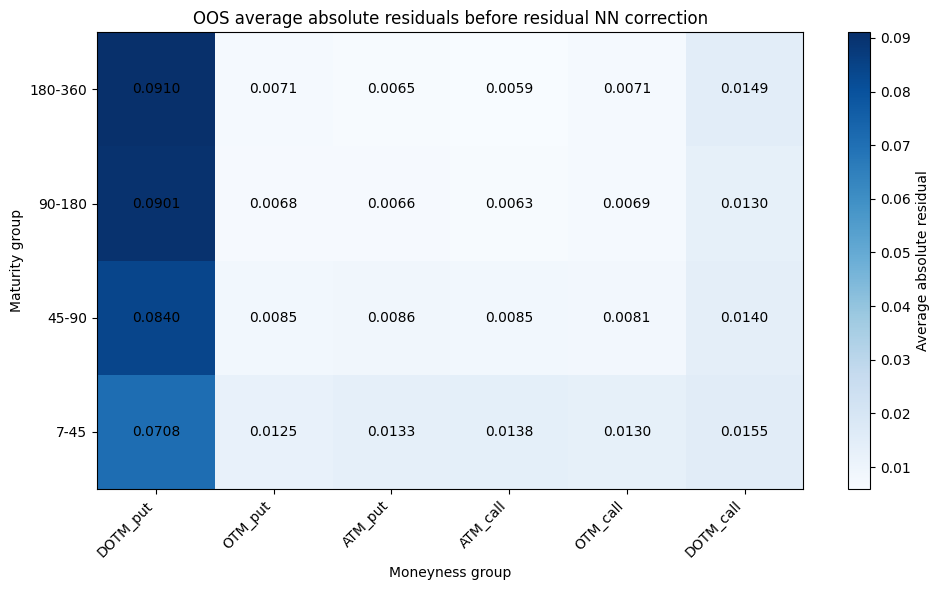

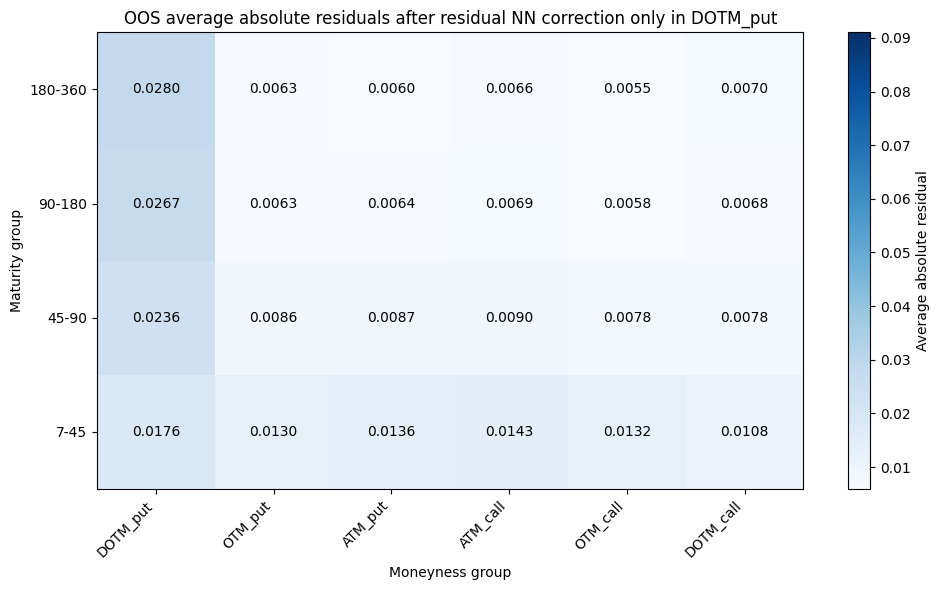

In [56]:
# Heatmap function
def make_oos_nn_heatmap(data_heatmap, value_col, title, vmin=None, vmax=None):

    # Moneyness and maturity orders
    maturity_order = ["7-45", "45-90", "90-180", "180-360"]
    moneyness_order = ["DOTM_put", "OTM_put", "ATM_put", "ATM_call", "OTM_call", "DOTM_call"]

    # Copy the data
    data_heatmap = data_heatmap.copy()

    # Ensure fixed order
    data_heatmap["maturity_group"] = pd.Categorical(data_heatmap["maturity_group"], categories=maturity_order, ordered=True)

    # Ensure fixed order
    data_heatmap["moneyness_group"] = pd.Categorical(data_heatmap["moneyness_group"], categories=moneyness_order, ordered=True)

    # Create heatmap table
    heatmap_table = data_heatmap.pivot_table(values=value_col, index="maturity_group", columns="moneyness_group", aggfunc="mean", observed=False).reindex(index=maturity_order, columns=moneyness_order)

    # Customize plotting environment
    fig, ax = plt.subplots(figsize=(10, 6))

    # Draw the actual heatmap
    im = ax.imshow(heatmap_table, aspect="auto", cmap="Blues", vmin=vmin, vmax=vmax)

    # Loop over the rows
    for i in range(heatmap_table.shape[0]):

        # Loop over the columns
        for j in range(heatmap_table.shape[1]):

            # Get the corresponding value
            value = heatmap_table.iloc[i, j]
            label = f"{value:.4f}"

            # Place the label in the correct spot
            ax.text(j, i, label, ha="center", va="center")

    # Invert the y-axis
    ax.invert_yaxis()

    # Customize labels
    ax.set_xticks(range(len(moneyness_order)))
    ax.set_xticklabels(moneyness_order, rotation=45, ha="right")
    ax.set_yticks(range(len(maturity_order)))
    ax.set_yticklabels(maturity_order)
    ax.set_xlabel("Moneyness group")
    ax.set_ylabel("Maturity group")
    ax.set_title(title)

    # Set colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Average absolute residual")

    # Plot the results
    fig.tight_layout()
    plt.show()

    # Return the results
    return heatmap_table

# Create prior heatmap
heatmap_oos_prior = make_oos_nn_heatmap(x_test_nn,value_col="abs_error_prior",title="OOS average absolute residuals before residual NN correction")

# Ensure common scale
vmin_common = heatmap_oos_prior.min().min()
vmax_common = heatmap_oos_prior.max().max()

# Create NN heatmap
heatmap_oos_nn = make_oos_nn_heatmap(x_test_nn, value_col="abs_error_nn", title="OOS average absolute residuals after residual NN correction only in DOTM_put", vmin=vmin_common, vmax=vmax_common)

- **Create surface plots**

In [ ]:
# Specify dates
plot_date = pd.Timestamp("2019-06-12").date()

# Filter observations for the plot date
surface_date = x_test_nn[pd.to_datetime(x_test_nn["quote_date"]).dt.date.eq(plot_date)].copy()

# Keep only the put options
surface_date = surface_date[surface_date["moneyness_group"].isin(["DOTM_put", "OTM_put", "ATM_put"])].copy()

# Plotting function
def plot_trisurf_surface(data, value_col, zlabel, save_path=None):

    # Specify the plotting data
    plot_data = data[["delta_fun", "T", value_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()

    # x, y, z axis
    x = plot_data["delta_fun"].to_numpy(dtype=float)
    y = plot_data["T"].to_numpy(dtype=float)
    z = plot_data[value_col].to_numpy(dtype=float)

    # Plotting environment
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")

    # 3D surface
    ax.plot_trisurf(x, y, z, cmap='viridis', edgecolor="none", antialiased=True, alpha=0.9)

    # Adjust labels
    ax.set_xlabel(r"$\Delta$-moneyness", labelpad=10)
    ax.set_ylabel("Time to maturity (years)", labelpad=10)
    ax.set_zlabel(zlabel, labelpad=10)
    ax.invert_xaxis()

    # Custom gridlines
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)

    # Tight layout
    plt.tight_layout()

    # Save figure
    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight", dpi=300)

    # Plot the results
    plt.show()

# Plot the observed IV surface
plot_trisurf_surface(surface_date, "iv_fun", "Implied volatility", save_path="/Users/euanbronsky/Downloads/surface_observed_put_iv_2019_06_12.png")

# Plot spline prior IV surface
plot_trisurf_surface(surface_date, "iv_prior", "Implied volatility", save_path="/Users/euanbronsky/Downloads/surface_spline_prior_put_iv_2019_06_12.png")

# Plot corrected IV surface
plot_trisurf_surface(surface_date, "iv_nn", "Implied volatility", save_path="/Users/euanbronsky/Downloads/surface_nn_corrected_put_iv_2019_06_12.png")

- **Residual plots**

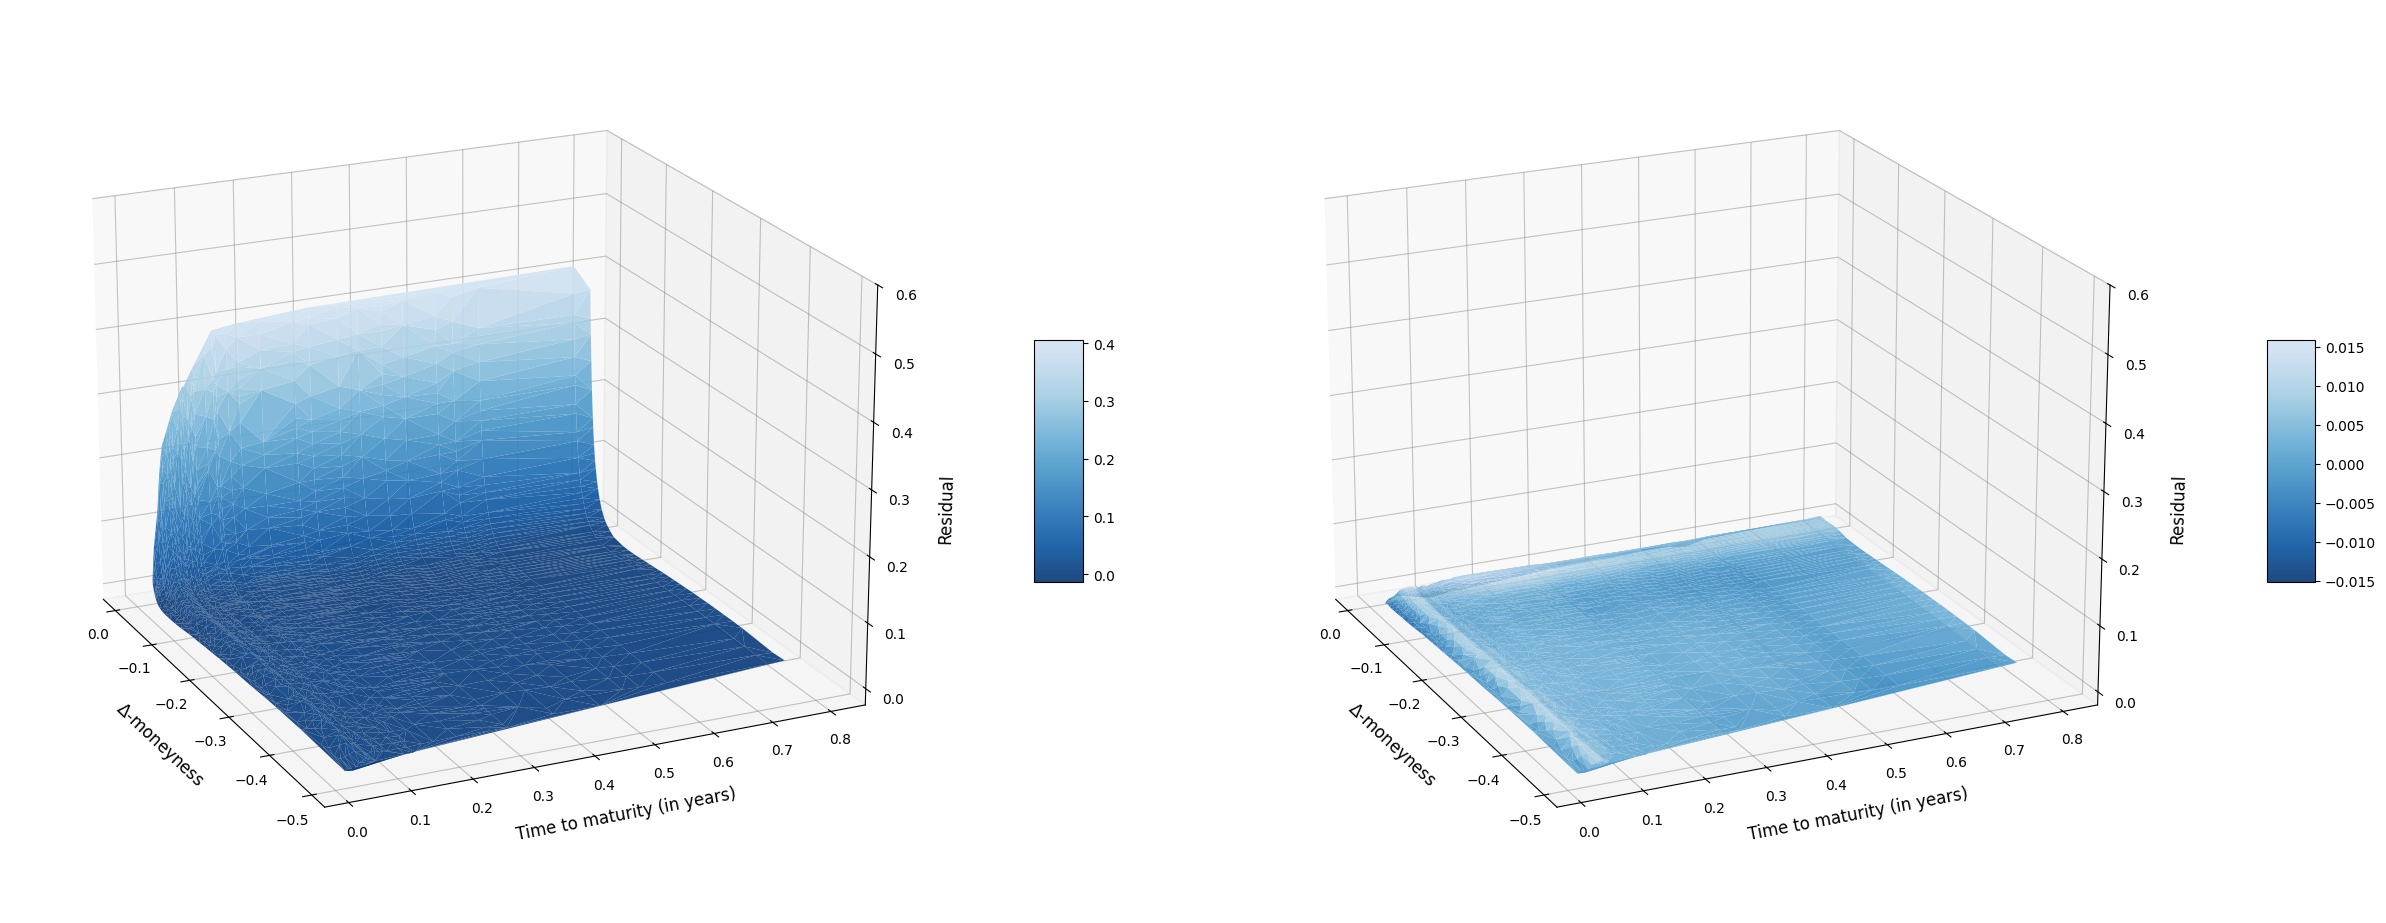

In [61]:
# Custom color map
blues_no_white = LinearSegmentedColormap.from_list("blues_no_white", cm.Blues_r(np.linspace(0.02, 0.82, 256)))

# Compute prior residual
surface_date["residual_prior"] = (surface_date["iv_fun"] - surface_date["iv_prior"])

# Compute corrected residual
surface_date["residual_nn_corrected"] = (surface_date["iv_fun"] - surface_date["iv_nn"])

# Set plottign environment
fig, axes = plt.subplots(1, 2, figsize=(25, 10), subplot_kw={"projection": "3d"})
fig.subplots_adjust(wspace=3)

# Plot residual surface before NN correction
d1 = surface_date[["delta_fun", "T", "residual_prior"]].dropna()
surf1 = axes[0].plot_trisurf(d1["delta_fun"], d1["T"], d1["residual_prior"],
                             cmap=blues_no_white, edgecolor="none", alpha=0.9,
                             antialiased=True)

# Set labels
axes[0].set_xlabel(r"$\Delta$-moneyness", labelpad=10, fontsize = 12)
axes[0].set_ylabel("Time to maturity (in years)", labelpad=10, fontsize = 12)
axes[0].set_zlabel("Residual", labelpad=10, fontsize = 12)
axes[0].set_zlim(top=0.6)
axes[0].invert_xaxis()

# Plot residual surface after NN correction
d2 = surface_date[["delta_fun", "T", "residual_nn_corrected"]].dropna()
surf2 = axes[1].plot_trisurf(d2["delta_fun"], d2["T"], d2["residual_nn_corrected"],cmap=blues_no_white, edgecolor="none", alpha=0.9, antialiased=True)

# Set labels
axes[1].set_xlabel(r"$\Delta$-moneyness", labelpad=10, fontsize = 12)
axes[1].set_ylabel("Time to maturity (in years)", labelpad=10, fontsize = 12)
axes[1].set_zlabel("Residual", labelpad=10, fontsize = 12)
axes[1].set_zlim(top=0.6)
axes[1].invert_xaxis()

# Set specifics
for ax in axes:
    ax.xaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.yaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.zaxis._axinfo["grid"]["color"] = (0.5, 0.5, 0.5, 0.45)
    ax.view_init(elev=20, azim=-25)

# Color bars
fig.colorbar(surf1, ax=axes[0], shrink=0.25, aspect=5, pad=0.1)
fig.colorbar(surf2, ax=axes[1], shrink=0.25,aspect=5, pad=0.1)

# Plot the results
plt.tight_layout()
plt.savefig("/Users/euanbronsky/Downloads/resid.surfaces.png",bbox_inches="tight", dpi=300)
plt.show()

- **Save the results**

In [ ]:
# Store predictions in DF
nn_predictions = {
    'x_test_nn': x_test_nn,}

# Save using Pickle
with open("/Users/euanbronsky/PyCharmMiscProject/x_test_nn.pkl", "wb") as f:
    pickle.dump(nn_predictions, f)